In [ ]:
#create a 2d grid of points 1000 x 1000

grid_res = 0.1
zsize = 100/grid_res
xsize = 150/grid_res


# zrange = LinRange(-100, 100, grid_size)
zrange = collect(-zsize:grid_res:zsize)
# xrange = LinRange(-100, 100, grid_size)
xrange = collect(-xsize:grid_res:xsize)
points = [(zi, xi) for zi in zrange, xi in xrange]
#flatten the points array
points = reshape(points, :, 1)
# #convert to matrix
# points = hcat(points...)
#convert to array of tuples
# points = [(points[1, i], points[2, i]) for i in 1:size(points, 2)]
# #convert to array of arrays
# points = [[points[i][1], points[i][2]] for i in 1:length(points)]



In [20]:
#create a function that takes in a point and returns the distance to the origin
distance_to_origin(point) = sqrt(point[1]^2 + point[2]^2)
#apply the function to all points in the grid
distances = [distance_to_origin(point) for point in points]
#reshape distances to a 1000 x 1000 matrix
distances = reshape(distances, zsize, xsize)
#convert distances to a heatmap (ploting using CairoMakie)
using CairoMakie
heatmap(distances, colormap = :viridis)


DimensionMismatch: DimensionMismatch: new dimensions (100, 150) must be consistent with array size 6005001

In [15]:
#create a function (velocity field) that takes in a point and returns a vector (vz, vx) where vz = z/distance^2 and vx = x/distance^2
rstar = 10.0
velocity_field(point) = 
    begin
    dist = distance_to_origin(point)
    if dist <= rstar
        return (0.0, 0.0)
    else
        vz = point[1] / dist^2
        vx = point[2] / dist^2
        return (vz, vx)
    end
end

velocity_field (generic function with 1 method)

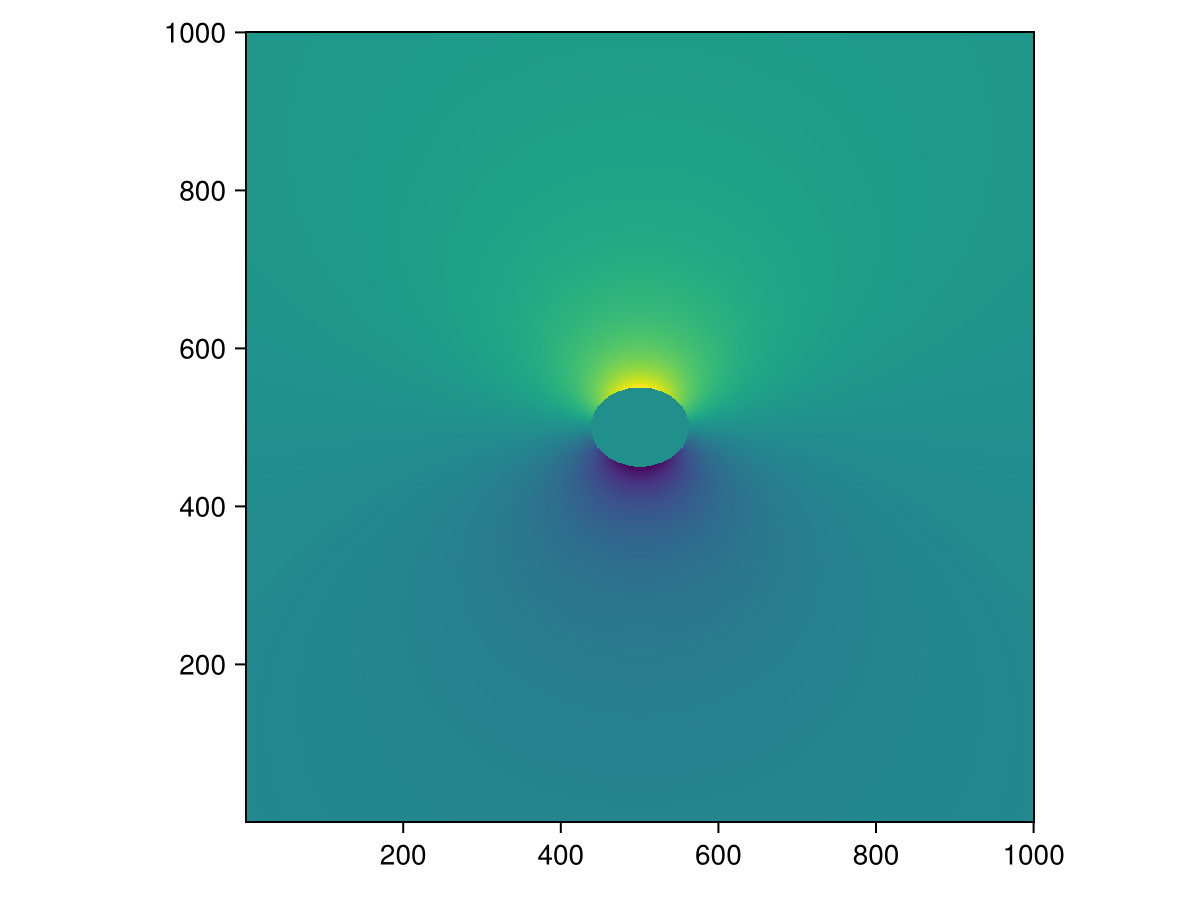

In [10]:
#apply the function to all points in the grid and plot 
velocities = [velocity_field(point) for point in points]
#reshape velocities to a 1000 x 1000 matrix of tuples
velocities = reshape(velocities, grid_size, grid_size)
#convert velocities to two matrices vx and vy
vz = [velocities[i, j][1] for i in 1:grid_size, j in 1:grid_size]
vx = [velocities[i, j][2] for i in 1:grid_size, j in 1:grid_size]
#plot the y component of the velocity field as a heatmap. The plot has a 1:1 aspect ratio
# heatmap(vx, colormap = :viridis)
heatmap(vx, colormap = :viridis, axis = (aspect = DataAspect(),))

#plot the velocity field as a arrow plot
# using CairoMakie
# fig = Figure()
# Axis(fig[1, 1], aspect = DataAspect())
# arrows!(x, y, vx, vy)
# fig



